# Automated Fabric Defect Classification — Dataset Exploration

**Notebook 01** of the fabric defect classification pipeline.

Before building any model, we need to understand the data we are working with. This notebook looks at the fabric defect images and answers some basic questions: How many images are there? How are they organised? Are some defect types much rarer than others? Are any files broken or duplicated?

The answers decide how we clean and prepare the images in Notebook 02.

## 1. Import Libraries

**What:** Load the tools we need.

**Why:** `os` and `pathlib` let us move through folders and list files. `PIL` opens images and tells us their size and colour type. `matplotlib` draws charts and displays pictures. `Counter` counts things quickly.

In [1]:
import os
import random
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
from PIL import Image

## 2. Load Dataset

**What:** Download the fabric defect images from Kaggle.

**Why:** The dataset is about 2.1 GB, which is far too large to store in a GitHub repository. Instead of saving the images, we download them fresh each time the notebook runs. This keeps the repo small and means anyone can reproduce our work.

**Dataset details:**

- **Source:** Kaggle — `ziya07/multi-class-fabric-defect-detection-dataset` (version 3)
- **Size:** ~2.1 GB, 3,067 image files in 9 folders
- **Licence:** _(fill in from the dataset's Kaggle page)_

In [2]:
import kagglehub

path = kagglehub.dataset_download("ziya07/multi-class-fabric-defect-detection-dataset")
print("Dataset downloaded to:", path)

ds2 = os.path.join(path, "Dataset")

Using Colab cache for faster access to the 'multi-class-fabric-defect-detection-dataset' dataset.
Dataset downloaded to: /kaggle/input/multi-class-fabric-defect-detection-dataset


## 3. Explore Dataset Structure

**What:** List the folders inside the dataset.

**Why:** Each folder should hold one type of fabric defect, with the folder name acting as the label. We check this before anything else, because if the folders are not arranged the way we expect, every later step would be counting the wrong thing.

**Observations:** There are exactly 9 folders, matching the 9 classes described by the dataset. One of them is called **"defect free"** — this is important, because it means the dataset contains normal fabric as well as defective fabric. The model will therefore be able to answer both *"is there a defect?"* and *"what kind of defect is it?"*.

Note that the folder names are inconsistently capitalised (`Broken stitch`, `defect free`, `hole`), so we always read them from the folder list rather than typing them by hand.

In [3]:
class_names = sorted(os.listdir(ds2))
print(f"Number of classes: {len(class_names)}\n")
for cls in class_names:
    print(" -", cls)

Number of classes: 9

 - Broken stitch
 - Needle mark
 - Pinched fabric
 - Vertical
 - defect free
 - hole
 - horizontal
 - lines
 - stain


## 4. Count Images per Class

**What:** Count how many images are in each class folder.

**Why:** In real factories, most fabric is fine and only a small amount is defective, so these datasets usually contain far more normal images than defective ones. This matters a lot: if one class is much bigger than the others, a model can score well simply by always guessing that class, without learning anything useful. We need to know the sizes before we choose how to train.

**Observations:** The classes are very unevenly sized. "defect free" alone holds 1,666 of the 3,067 images (54.3%), while the smallest class, "Vertical", has only 101 (3.3%) — roughly 16 times fewer. This confirms the dataset is imbalanced, and we will need to correct for it during training.

In [4]:
class_counts = {
    cls: len(list((Path(ds2) / cls).glob("*")))
    for cls in class_names
}

total = sum(class_counts.values())
print(f"Total images: {total}\n")
for cls, count in sorted(class_counts.items(), key=lambda x: -x[1]):
    print(f"{cls:20s} {count:5d}  ({count / total:.1%})")

Total images: 3067

defect free           1666  (54.3%)
stain                  398  (13.0%)
hole                   281  (9.2%)
lines                  157  (5.1%)
horizontal             136  (4.4%)
Broken stitch          112  (3.7%)
Needle mark            108  (3.5%)
Pinched fabric         108  (3.5%)
Vertical               101  (3.3%)


## 5. Plot Class Distribution

**What:** Draw the counts from the previous step as a bar chart.

**Why:** A chart shows the imbalance instantly, in a way a column of numbers does not. Seeing how far one bar towers over the others makes it obvious how much correction the training step will need.

**Observations:** The imbalance is severe. The "defect free" bar is several times taller than every other bar, and the smallest classes are barely visible next to it. This tells us that plain accuracy will be a misleading way to measure success, and that we will need to give the rare classes extra weight when training.

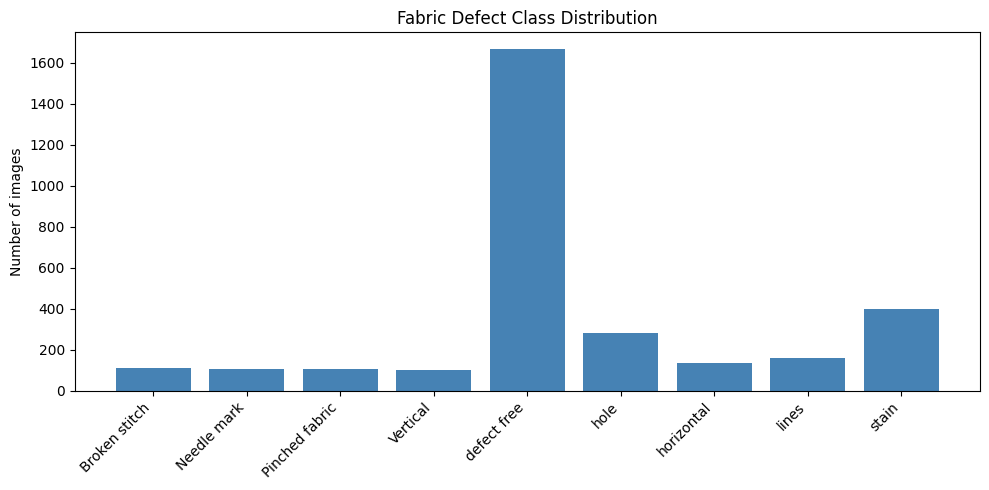

In [5]:
plt.figure(figsize=(10, 5))
plt.bar(class_counts.keys(), class_counts.values(), color="steelblue")
plt.title("Fabric Defect Class Distribution")
plt.ylabel("Number of images")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 6. Display Sample Images

**What:** Show one random image from each class.

**Why:** Looking at real examples builds an understanding of what each defect actually looks like — how a hole differs from a stain, or a needle mark from a broken stitch. It can also reveal problems that numbers alone would hide.

**Observations:** The images do not all look the same way. "Broken stitch", "Needle mark" and "Pinched fabric" appear as normal fabric photographs where the weave is clearly visible. But "Vertical" and "horizontal" appear in strange purple and yellow colours, "hole" looks almost completely black, and "lines" and "stain" have odd colour tints.

At first this looks like the images might be in the wrong folders. They are not. The explanation is how images are stored:

- A **colour image** stores three numbers for each pixel — how much red, green and blue it contains.
- A **grayscale image** stores only one number per pixel — how bright it is, with no colour at all.

When we display a grayscale image, matplotlib has brightness values but no colours to go with them, so it invents a colour scheme called *viridis*: dark values become purple, bright values become yellow. That is exactly what we are seeing. Look closely at the "Vertical" image and you can see bright yellow streaks — those streaks **are** the vertical defect. It was there all along, just painted in false colours.

So the labels are correct; the images are simply stored in different colour formats. Sections 12 to 15 confirm this properly. The fix is to convert every image to colour format before using it, which becomes a step in Notebook 02.

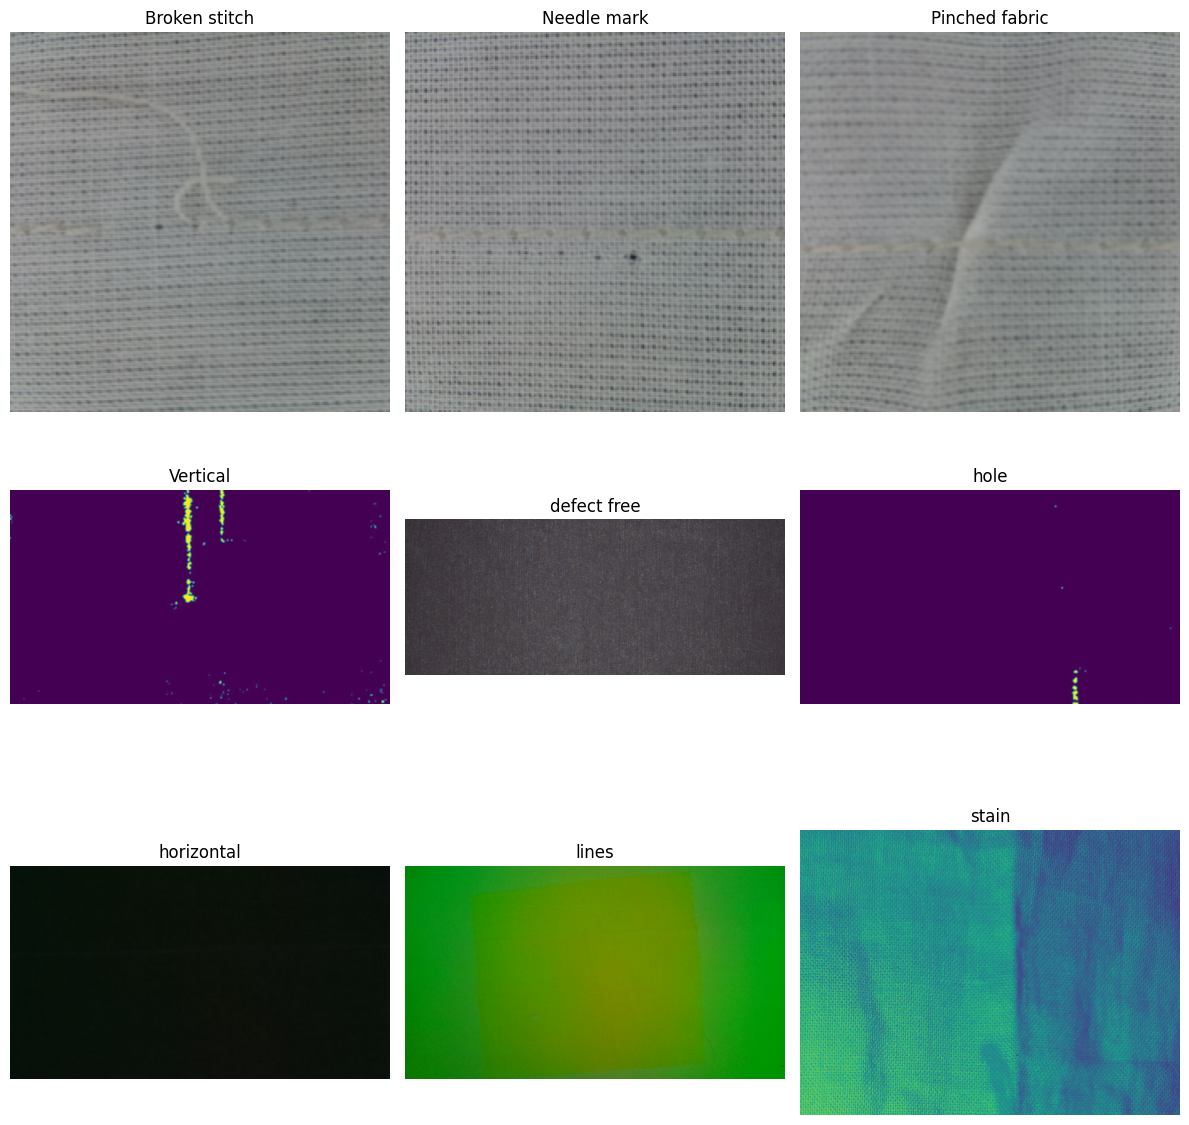

In [6]:
fig, axes = plt.subplots(3, 3, figsize=(12, 12))

for ax, cls in zip(axes.flat, class_names):
    img_files = list((Path(ds2) / cls).glob("*"))
    sample_path = random.choice(img_files)
    img = Image.open(sample_path)
    ax.imshow(img)
    ax.set_title(cls)
    ax.axis("off")

plt.tight_layout()
plt.show()

## 7. Check Image Sizes

**What:** Measure the width and height of every image.

**Why:** A neural network needs every image fed into it to be exactly the same size. If the images already share one size, we can use them as they are. If they vary, we must resize them — and how we resize matters, because careless resizing can squash or stretch a defect out of shape.

**Observations:** The sizes vary enormously. Widths run from 201 to 4,608 pixels and heights from 224 to 3,456 pixels — the largest images are over twenty times wider than the smallest. However, only 13 different sizes appear across all 3,067 images, meaning images arrive in a small number of fixed sizes rather than being all different. This is another clue that the dataset was built from several separate collections. Every image will need resizing to one common size.

In [7]:
sizes = []
for cls in class_names:
    for img_path in (Path(ds2) / cls).glob("*"):
        try:
            with Image.open(img_path) as img:
                sizes.append(img.size)
        except Exception:
            pass

widths, heights = zip(*sizes)
print(f"Checked {len(sizes)} images")
print(f"Width  - min: {min(widths)}, max: {max(widths)}, avg: {sum(widths)/len(widths):.0f}")
print(f"Height - min: {min(heights)}, max: {max(heights)}, avg: {sum(heights)/len(heights):.0f}")
print(f"Unique sizes: {len(set(sizes))}")

Checked 3067 images
Width  - min: 201, max: 4608, avg: 1866
Height - min: 224, max: 3456, avg: 891
Unique sizes: 13


## 8. Check File Formats

**What:** Check what file types the images are saved as.

**Why:** Different formats store images differently. JPEG compresses images and loses a little detail; PNG keeps every pixel exactly and can also store transparency. Knowing the mix tells us whether we need to handle any format specially. We also compare the file extension against the format PIL actually detects, in case a file has been given the wrong extension.

**Observations:** The dataset is mostly JPEG — 2,917 files (about 95%) — with 150 PNG files (about 5%). Every file's extension matches what PIL detects inside it, so no file is mislabelled. Because PNG files can carry a transparency channel that JPEGs do not have, we will convert everything to plain colour format during preprocessing so the model receives consistent input.

In [8]:
extensions = Counter()
formats = Counter()

for cls in class_names:
    for img_path in (Path(ds2) / cls).glob("*"):
        extensions[img_path.suffix.lower()] += 1
        try:
            with Image.open(img_path) as img:
                formats[img.format] += 1
        except Exception:
            pass

print("File extensions:", dict(extensions))
print("PIL-detected formats:", dict(formats))

File extensions: {'.jpg': 2917, '.png': 150}
PIL-detected formats: {'JPEG': 2917, 'PNG': 150}


## 9. Check for Missing or Corrupted Images

**What:** Try to open every single image, and flag any that are empty or fail to load.

**Why:** Training a model means reading thousands of images one after another. A single broken file will crash the process partway through — often after it has already run for a long time. Finding those files now takes seconds; discovering them mid-training wastes hours.

**Observations:** Every file opened successfully. There are no empty (zero-byte) files and no corrupted files. The dataset is sound from a file-integrity point of view, so nothing needs to be excluded for this reason.

In [9]:
corrupted = []
zero_byte = []

for cls in class_names:
    for img_path in (Path(ds2) / cls).glob("*"):
        if img_path.stat().st_size == 0:
            zero_byte.append(img_path)
            continue
        try:
            with Image.open(img_path) as img:
                img.verify()
        except Exception as e:
            corrupted.append((img_path, str(e)))

print(f"Zero-byte files: {len(zero_byte)}")
print(f"Corrupted files: {len(corrupted)}")

for p in zero_byte:
    print(" [empty]    ", p)
for p, err in corrupted:
    print(" [corrupted]", p, "-", err)

Zero-byte files: 0
Corrupted files: 0


## 10. Inspect Filenames for Grouping Information

**What:** Print the first few filenames from each class folder.

**Why:** Factory datasets are often photographed in sessions — many pictures taken of the same roll of fabric. This creates a hidden trap. If several photos of one roll end up split between the training set and the test set, the model can recognise that specific roll from training rather than learning what the defect looks like. Its test score would then look excellent while meaning nothing. Filenames are the only place such grouping information might be recorded, so we look there.

**Observations:** There are **no fabric roll or batch identifiers** anywhere in the filenames. But the names reveal two other things:

1. **Copies of the same image.** In "Vertical", "hole" and "horizontal" we see files like `10.jpg` sitting alongside `10_processed (1).jpg`, `10_processed (2).jpg` and `10_processed (3).jpg`. These are altered versions made from one original picture.
2. **Several different naming styles.** "Broken stitch", "Needle mark" and "Pinched fabric" use a tidy code (`A_02_001.jpg`, `A_08_001.jpg`, `A_03_001.jpg`); "lines" uses camera timestamps (`20180531_140300.jpg`); "stain" uses plain numbers; "defect free" starts with `0001_000_00.png`.

Different naming styles usually mean different original sources. So this dataset appears to have been assembled from several separate collections — something we investigate in Section 14.

In [11]:
for cls in class_names:
    files = sorted(p.name for p in (Path(ds2) / cls).glob("*"))
    print(f"\n{cls} ({len(files)} files):")
    for f in files[:8]:
        print("   ", f)


Broken stitch (112 files):
    A_02_001.jpg
    A_02_002.jpg
    A_02_003.jpg
    A_02_004.jpg
    A_02_005.jpg
    A_02_006.jpg
    A_02_007.jpg
    A_02_008.jpg

Needle mark (108 files):
    A_08_001.jpg
    A_08_002.jpg
    A_08_003.jpg
    A_08_004.jpg
    A_08_005.jpg
    A_08_006.jpg
    A_08_007.jpg
    A_08_008.jpg

Pinched fabric (108 files):
    A_03_001.jpg
    A_03_002.jpg
    A_03_003.jpg
    A_03_004.jpg
    A_03_005.jpg
    A_03_006.jpg
    A_03_007.jpg
    A_03_008.jpg

Vertical (101 files):
    1.jpg
    10.jpg
    10_processed (1).jpg
    10_processed (2).jpg
    10_processed (3).jpg
    11.jpg
    11_processed (1).jpg
    11_processed (2).jpg

defect free (1666 files):
    0001_000_00.png
    0001_000_01.png
    0001_000_02.png
    0001_000_03.png
    0001_000_04.png
    0001_000_05.png
    0001_000_06.png
    0002_000_00.png

hole (281 files):
    1.jpg
    10.jpg
    10_processed (1).jpg
    10_processed (2).jpg
    10_processed (3).jpg
    11.jpg
    11_processed

## 11. Count the Duplicate Copies

**What:** Remove the `_processed (N)` ending from each filename to find the original image it came from, then compare the number of files against the number of genuinely different images.

**Why:** We need to know how much of the dataset is real, independent data and how much is just copies. Copies matter for two reasons: they make the dataset look bigger than it is, and if a copy lands in the test set while its original is in the training set, the model is being tested on something it has already memorised.

**Observations:** Three classes contain copies:

| Class | Files | Different images | Copies per image |
|---|---:|---:|---:|
| horizontal | 136 | 34 | 4.00 |
| Vertical | 101 | 32 | 3.16 |
| hole | 281 | 143 | 1.97 |

The other six classes have no copies at all. This changes the picture considerably: the dataset holds **2,758 genuinely different images**, not 3,067. More seriously, "Vertical" and "horizontal" turn out to have only about **32 and 34 real images each** — far fewer than their file counts suggested.

In [10]:
import re
from collections import defaultdict

def base_id(p):
    return re.sub(r'_processed.*$', '', Path(p).stem)

print(f"{'Class':20s} {'Files':>7s} {'Unique':>7s} {'Ratio':>7s}")
for cls in class_names:
    files = list((Path(ds2) / cls).glob("*"))
    uniq = {base_id(p) for p in files}
    print(f"{cls:20s} {len(files):7d} {len(uniq):7d} {len(files)/len(uniq):7.2f}")

Class                  Files  Unique   Ratio
Broken stitch            112     112    1.00
Needle mark              108     108    1.00
Pinched fabric           108     108    1.00
Vertical                 101      32    3.16
defect free             1666    1666    1.00
hole                     281     143    1.97
horizontal               136      34    4.00
lines                    157     157    1.00
stain                    398     398    1.00


## 12. Find Exact Duplicates by File Content

**What:** Create a fingerprint (an MD5 hash) of every file's exact contents, then look for files sharing the same fingerprint.

**Why:** Section 11 found copies by looking at *filenames*, but that only catches copies that are named like copies. If the same image were saved twice under two completely unrelated names, that check would miss it. Comparing the actual file contents catches duplicates no matter what they are called.

We pay special attention to duplicates found in **different class folders**. If one identical image appears under two different labels, that is a genuine contradiction — the same picture cannot be both a hole and a stain.

**Observations:** There are 17 duplicate files hiding under different names — a small number, easily removed.

The important result is the second one: **zero duplicate groups span multiple classes.** No image carries two conflicting labels anywhere in this dataset. Together with Section 15, this finally settles the worry raised back in Section 6 — the images are not mislabelled.

In [15]:
import hashlib
from collections import defaultdict

hashes = defaultdict(list)
for cls in class_names:
    for p in (Path(ds2) / cls).glob("*"):
        h = hashlib.md5(p.read_bytes()).hexdigest()
        hashes[h].append(f"{cls}/{p.name}")

dupes = {h: v for h, v in hashes.items() if len(v) > 1}
print(f"Exact-duplicate groups : {len(dupes)}")
print(f"Redundant files        : {sum(len(v) - 1 for v in dupes.values())}")

cross = [v for v in dupes.values() if len({f.split('/')[0] for f in v}) > 1]
print(f"\nGroups spanning MULTIPLE classes: {len(cross)}")
for g in cross[:10]:
    print("  ", g)

Exact-duplicate groups : 17
Redundant files        : 17

Groups spanning MULTIPLE classes: 0


## 13. Find Near-Duplicate Images

**What:** Compare how images *look*, rather than whether their files are byte-for-byte identical.

**Why:** Two checks are still not enough. If someone opened an image and saved it again — perhaps at slightly different quality — the file contents would change but the picture would stay the same. The MD5 check in Section 12 would miss that entirely, yet it is still a duplicate as far as the model is concerned.

There is a second reason too. Photographs taken of the same fabric in the same session look very similar to each other. If we can find those clusters, we could group them and keep each group entirely inside one split — giving us a stand-in for the fabric-roll information the dataset does not provide.

To compare appearance we shrink each image down to a tiny grid and turn its brightness pattern into a short code. Similar-looking pictures produce the same code. This first attempt shrinks images to 8×8 pixels.

**Observations:** This flagged 1,494 images — **54% of the entire dataset** — as near-duplicates, which is far too many to believe. The output shows why it cannot be trusted: one cluster groups a broken-stitch image together with ten defect-free images, and another pairs a studio fabric close-up with a phone photograph from a different collection. Those pictures are plainly different.

The problem is that 8×8 is too coarse. Fabric close-ups are low-contrast and almost uniform in texture, so once shrunk to 64 pixels they all look alike and many produce the same code by accident. These are collisions, not duplicates. We need a more detailed comparison.

In [16]:
def phash(p, size=8):
    with Image.open(p) as img:
        small = img.convert("L").resize((size, size), Image.BILINEAR)
    px = list(small.getdata())
    avg = sum(px) / len(px)
    return "".join("1" if v > avg else "0" for v in px)

groups = defaultdict(list)
for cls in class_names:
    for p in (Path(ds2) / cls).glob("*"):
        if "_processed" in p.name:
            continue
        groups[phash(p)].append(f"{cls}/{p.name}")

near = {h: v for h, v in groups.items() if len(v) > 1}
print(f"Near-duplicate clusters: {len(near)}")
print(f"Images involved        : {sum(len(v) for v in near.values())}")
for v in list(near.values())[:10]:
    print("  ", v)

Near-duplicate clusters: 241
Images involved        : 1494
   ['Broken stitch/A_02_105.jpg', 'Broken stitch/A_02_110.jpg', 'Broken stitch/A_02_022.jpg', 'Broken stitch/A_02_112.jpg', 'Broken stitch/A_02_099.jpg']
   ['Broken stitch/A_02_090.jpg', 'Broken stitch/A_02_021.jpg', 'Broken stitch/A_02_086.jpg']
   ['Broken stitch/A_02_103.jpg', 'Broken stitch/A_02_100.jpg']
   ['Broken stitch/A_02_084.jpg', 'Broken stitch/A_02_089.jpg']
   ['Broken stitch/A_02_052.jpg', 'Broken stitch/A_02_085.jpg']
   ['Broken stitch/A_02_030.jpg', 'Broken stitch/A_02_031.jpg']
   ['Broken stitch/A_02_077.jpg', 'Pinched fabric/A_03_096.jpg']
   ['Broken stitch/A_02_098.jpg', 'Broken stitch/A_02_097.jpg']
   ['Broken stitch/A_02_027.jpg', 'defect free/0004_000_00.png', 'defect free/0008_000_00.png', 'defect free/0009_000_00.png', 'defect free/0007_000_00.png', 'defect free/0002_000_00.png', 'defect free/0001_000_00.png', 'defect free/0005_000_00.png', 'defect free/0003_000_00.png', 'defect free/0010_000_00.p

### 13b. A More Detailed Comparison

**What:** Repeat the check with a finer method — a 16×16 difference hash, which compares each pixel against its neighbour instead of against the image's average brightness — and only compare images within the same class.

**Why:** Comparing neighbouring pixels captures edges and texture detail, which survives shrinking far better than overall brightness does. This suits low-contrast fabric images much better. Using a 16×16 grid also produces a code four times longer than before, making accidental matches far less likely. Finally, we display one cluster on screen, because a number alone does not prove the method works — we should be able to see that the images really are near-identical.

**Observations:** The count drops from 54% to **19 clusters covering 40 images — just 1.5% of the dataset**, in 18 pairs and one group of four. The displayed cluster confirms it: four images of the same white line on a black background, indistinguishable by eye.

The filenames explain what these really are:

```
exp2_num_249619.png  +  exp2_num_249619 - Copy.png
20180531_135032.jpg  +  20180531_135032(1).jpg
```

Endings like `- Copy` and `(1)` come from copying files on a computer or downloading the same file twice. These are accidents from assembling the dataset, not separate photographs. Three "defect free" clusters have unrelated names and do appear to be genuine repeat shots.

**Two conclusions:**

1. Only 40 images are affected. We keep one image from each cluster and drop the rest, so no near-identical pair can be split across training and testing.
2. **No fabric-roll grouping exists in this data.** The clusters are file-copying accidents, not shooting sessions. Notice also that the coarse method's apparent groupings of consecutively numbered files (`A_02_030`, `A_02_031`) disappeared completely here — they were collisions too. We therefore cannot group by roll, and we record this as a limitation rather than pretending otherwise.

In [19]:
def dhash(p, size=16):
    with Image.open(p) as img:
        small = img.convert("L").resize((size + 1, size), Image.BILINEAR)
    px = list(small.getdata())
    bits = []
    for row in range(size):
        for col in range(size):
            left  = px[row * (size + 1) + col]
            right = px[row * (size + 1) + col + 1]
            bits.append("1" if left > right else "0")
    return "".join(bits)

groups = defaultdict(list)
for cls in class_names:
    for p in (Path(ds2) / cls).glob("*"):
        if "_processed" in p.name:
            continue
        groups[(cls, dhash(p))].append(p.name)

near = {k: v for k, v in groups.items() if len(v) > 1}
involved = sum(len(v) for v in near.values())
print(f"Near-duplicate clusters : {len(near)}")
print(f"Images involved         : {involved} ({involved/clean_total:.1%} of dataset)")

from collections import Counter
print("Cluster sizes:", dict(Counter(len(v) for v in near.values())))
for (cls, _), v in list(near.items())[:10]:
    print(f"  {cls}: {v}")

Near-duplicate clusters : 19
Images involved         : 40 (1.5% of dataset)
Cluster sizes: {4: 1, 2: 18}
  Vertical: ['exp2_num_249619 - Copy.png', 'exp3_num_249637.png', 'exp2_num_249619.png', 'exp3_num_249637 - Copy.png']
  Vertical: ['exp6_num_249821.png', 'exp6_num_249821 - Copy.png']
  Vertical: ['exp1_num_249594.png', 'exp1_num_249594 - Copy.png']
  defect free: ['ad7de252558e171e0829121526.jpg', '9b40370baf474bdb0828541616.jpg']
  defect free: ['d181610ae81f07c71628340496.jpg', '5338c376ad6e0aef1628085156.jpg']
  defect free: ['154169072df34a990935125236.jpg', '30385c6b5177704c0940214496.jpg']
  hole: ['20180531_135032.jpg', '20180531_135032(1).jpg']
  hole: ['20180531_135129(1).jpg', '20180531_135129.jpg']
  lines: ['line_2018-10-10 10_29_47.995625.jpg', 'line_2018-10-10 10_29_47.995625(1).jpg']
  lines: ['line_2018-10-10 10_30_25.985902.jpg', 'line_2018-10-10 10_30_25.985902(1).jpg']


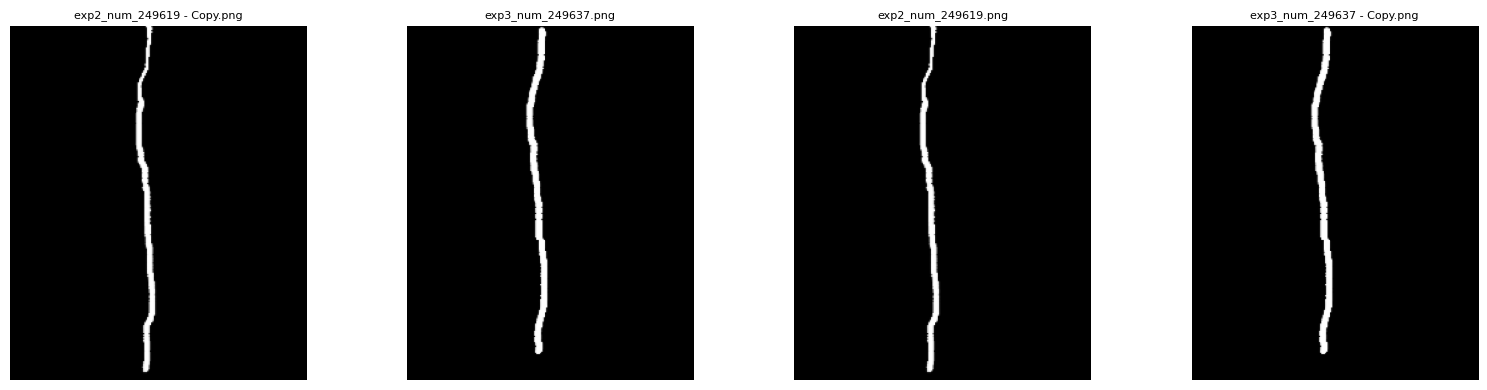

In [20]:
key, cluster = next(iter(near.items()))

if isinstance(key, tuple):          # dHash version: (class, hash)
    paths = [Path(ds2) / key[0] / n for n in cluster]
else:                               # older version: values are "class/name"
    paths = [Path(ds2) / c for c in cluster]

axes = plt.subplots(1, len(paths), figsize=(4 * len(paths), 4))[1]
if len(paths) == 1:
    axes = [axes]

for ax, p in zip(axes, paths):
    ax.imshow(Image.open(p).convert("RGB"))
    ax.set_title(p.name, fontsize=8)
    ax.axis("off")

plt.tight_layout()
plt.show()

## 14. Check Whether Classes Come from Different Sources

**What:** Sort every filename into a naming-style group and count the styles used in each class.

**Why:** This is the most important safety check in the notebook. Section 10 suggested the dataset was assembled from several collections. That would be dangerous if the normal images came from one collection and all the defective images from another, because the two groups would differ in camera, lighting and compression. A model could then reach a high score by spotting *which camera took the photo* rather than whether the fabric has a defect. It would appear to work and then fail completely on real factory images.

The test is simple: do normal and defective images ever come from the same source?

**Observations:** The dataset is confirmed to combine several collections — but the sources **overlap** between normal and defective classes:

- The `F_other` style makes up most of "defect free" (1,454 files) and is also the *only* style used by "Broken stitch" (112), "Needle mark" (108) and "Pinched fabric" (108).
- The `C_numeric` style appears in "defect free" (72) and also in "stain" (398), "horizontal" (34) and "Vertical" (23).

Because normal and defective images sit inside the same collections, the model cannot tell defective from normal just by recognising the source. This is the result we needed. Some risk from mixed sources remains, so we record it as a limitation, but the project rests on solid ground.

*Note:* `F_other` is a catch-all bucket and lumps the `A_NN_NNN` files in with other styles, so the real number of distinct sources is probably higher than this simple test shows.

In [12]:
def pattern(name):
    s = Path(name).stem
    if re.match(r'^\d{4}_\d{3}_\d{2}$', s):  return 'A_structured'
    if re.match(r'^\d+_processed', s):        return 'B_processed'
    if re.match(r'^\d+$', s):                 return 'C_numeric'
    if re.match(r'^\d{8}_\d{6}', s):          return 'D_timestamp'
    if s.startswith('line_'):                 return 'E_line_ts'
    return 'F_other'

for cls in class_names:
    c = Counter(pattern(p.name) for p in (Path(ds2) / cls).glob("*"))
    print(f"{cls:20s} {dict(c)}")

Broken stitch        {'F_other': 112}
Needle mark          {'F_other': 108}
Pinched fabric       {'F_other': 108}
Vertical             {'B_processed': 69, 'C_numeric': 23, 'F_other': 9}
defect free          {'A_structured': 140, 'F_other': 1454, 'C_numeric': 72}
hole                 {'B_processed': 138, 'F_other': 70, 'C_numeric': 46, 'D_timestamp': 17, 'E_line_ts': 10}
horizontal           {'B_processed': 102, 'C_numeric': 34}
lines                {'E_line_ts': 152, 'D_timestamp': 5}
stain                {'C_numeric': 398}


## 15. Check the Colour Format of the Copies

**What:** Compare the colour format of the original images against their `_processed` copies.

**Why:** Section 6 showed several classes displaying in strange false colours, and we suspected this was because those images are stored as grayscale rather than colour. This check tests that directly. It also looks for a second problem: if grayscale images exist in only a few classes, then "is this image grayscale?" quietly becomes a giveaway that the model could exploit instead of learning about defects.

**Observations:** **Every single** `_processed` file is grayscale (mode `L`), without exception:

| Class | Copies | Originals |
|---|---|---|
| Vertical | 69 grayscale | 23 colour, 9 grayscale |
| hole | 138 grayscale | 143 colour |
| horizontal | 102 grayscale | 34 colour |

This confirms the Section 6 mystery completely: the odd colours were a display effect, **not** wrong labels.

It also exposes the giveaway we were worried about. Grayscale copies exist in only three of the nine classes, so a model could learn the shortcut "grayscale means Vertical, hole or horizontal" instead of learning what those defects look like. Since these files are only altered versions of pictures we already have, they add no new information — so we remove them all during preprocessing, and create our own variations at training time, applied evenly across every class.

In [13]:
for cls in ["Vertical", "hole", "horizontal"]:
    modes = defaultdict(Counter)
    for p in (Path(ds2) / cls).glob("*"):
        with Image.open(p) as img:
            modes["processed" if "_processed" in p.name else "original"][img.mode] += 1
    print(f"{cls}: {dict((k, dict(v)) for k, v in modes.items())}")

Vertical: {'processed': {'L': 69}, 'original': {'RGB': 23, 'L': 9}}
hole: {'processed': {'L': 138}, 'original': {'RGB': 143}}
horizontal: {'processed': {'L': 102}, 'original': {'RGB': 34}}


## 16. The Real Class Distribution and a Baseline

**What:** Recount the classes with all the copies removed, then work out what score a model would get if it simply guessed the biggest class every single time.

**Why:** Every decision from here — how we split the data, how we weight the classes, which score we report — must be based on the real numbers rather than the inflated file count.

The guessing model matters because it sets the floor. It has learned nothing whatsoever, so whatever it scores is the score to beat. It also shows very clearly why we should not report accuracy as our headline number.

**Observations:** After removing the copies there are **2,758 real images**. The imbalance is now *worse* than it first appeared: "defect free" rises from 54.3% to **60.4%**, while "Vertical" and "horizontal" fall to just **1.2% each**. The largest class is **52 times** bigger than the smallest.

The baseline result is the striking part. A model that always answers "defect free" and never learns anything achieves:

- **60.4% accuracy** — which sounds almost respectable
- **0.084 macro F1** — which is close to zero

Both numbers describe the same useless model. Accuracy looks good only because it is dominated by the one huge class, while macro F1 treats all nine classes as equally important and correctly reports failure on eight of them.

This is why **macro F1 is our main measure**, with **per-class recall** reported separately so the rare defects cannot hide behind the common ones.

In [14]:
clean_counts = {
    cls: len([p for p in (Path(ds2) / cls).glob("*") if "_processed" not in p.name])
    for cls in class_names
}
clean_total = sum(clean_counts.values())

print(f"Unique images: {clean_total}  (raw file count: {total})\n")
print(f"{'Class':20s} {'Raw':>6s} {'Unique':>7s} {'Share':>8s}")
for cls, n in sorted(clean_counts.items(), key=lambda x: -x[1]):
    print(f"{cls:20s} {class_counts[cls]:6d} {n:7d} {n/clean_total:7.1%}")

majority = max(clean_counts, key=clean_counts.get)
p = clean_counts[majority] / clean_total
macro_f1 = (2 * p / (p + 1)) / len(class_names)

print(f"\nMajority-class baseline (always predict '{majority}'):")
print(f"  Accuracy          : {p:.1%}")
print(f"  Macro F1          : {macro_f1:.3f}")
print(f"  Imbalance ratio   : {max(clean_counts.values()) / min(clean_counts.values()):.0f}:1")

Unique images: 2758  (raw file count: 3067)

Class                   Raw  Unique    Share
defect free            1666    1666   60.4%
stain                   398     398   14.4%
lines                   157     157    5.7%
hole                    281     143    5.2%
Broken stitch           112     112    4.1%
Needle mark             108     108    3.9%
Pinched fabric          108     108    3.9%
horizontal              136      34    1.2%
Vertical                101      32    1.2%

Majority-class baseline (always predict 'defect free'):
  Accuracy          : 60.4%
  Macro F1          : 0.084
  Imbalance ratio   : 52:1


## 17. Summary

### Where the data came from

- **Source:** Kaggle — `ziya07/multi-class-fabric-defect-detection-dataset` (version 3)
- **Download size:** ~2.1 GB
- **Files in the download:** 3,067, across 9 folders
- **Genuinely different images:** 2,758
- **Licence:** _(fill in from the dataset's Kaggle page)_

### What we found

- **The classes:** 9 in total — 8 defect types plus 1 normal class ("defect free"). The dataset can therefore answer both *"is this fabric defective?"* and *"what kind of defect is it?"*.
- **Very uneven classes:** and it gets worse once copies are removed. "defect free" grows from 54.3% to 60.4%, while "Vertical" and "horizontal" shrink to about 1.2% each — roughly 32 and 34 images. The biggest class is 52 times the smallest.
- **Image sizes vary hugely:** from 201×224 up to 4,608×3,456 pixels, in 13 fixed sizes.
- **File types:** about 95% JPEG, 5% PNG.
- **File health:** no missing, empty or corrupted files.
- **Copies:** three classes contain altered duplicates (up to 4 per original), plus 17 exact duplicates under different names and 40 images in near-identical clusters. All would leak between training and testing if left in place.
- **Colour formats are mixed:** every `_processed` file is grayscale, and grayscale exists in only three classes — a shortcut the model could exploit.
- **No labelling errors:** no image appears under two different labels, so the concern raised in Section 6 is resolved.
- **Several sources combined:** but normal and defective images share sources, so a model cannot separate them by camera or lighting alone.

### The score to beat

A model that always guesses "defect free" gets **60.4% accuracy** but only **0.084 macro F1**. Accuracy is therefore misleading here. We use **macro F1** as our main measure and report **per-class recall** separately for the rare defects.

### What this means for Notebook 02

1. **Remove every `_processed` file** — they are grayscale copies that add no information and give the model a shortcut.
2. **Remove the 17 exact duplicates and the extra copies from the 19 near-duplicate clusters**, keeping one image from each.
3. **Convert every image to colour format**, so the JPEG/PNG and grayscale/colour differences disappear.
4. **Resize every image to 224×224.** How we resize needs care: "Vertical", "horizontal" and "lines" are defined by direction, so squashing an image could distort the very shape the model must recognise.
5. **Use cross-validation rather than one fixed split.** With only about 32 images, a normal 15% test share would leave "Vertical" with roughly 5 test images — far too few for a meaningful score. Cross-validation lets every image be tested once.
6. **Give rare classes extra weight during training**, and apply image variations evenly across all classes.

### What we could not do

- "Vertical" and "horizontal" have only about 32–34 real images each, so their individual scores will be uncertain no matter how good the model is.
- The dataset combines several collections. Sources do overlap between normal and defective images, but some source-related bias may still remain.
- **The dataset records no fabric roll or batch information.** We searched for it in the filenames and then tried to recover it by finding visually similar images, but the similar images turned out to be file-copying accidents rather than photographs from the same session. Splitting the data by production batch — the safest guard against this kind of leakage — is therefore not possible with this dataset, and we note it openly rather than assuming it does not matter.